In [1]:
import os
# Disable XLA completely
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_disable_all_hlo_passes'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf

# Disable XLA JIT compilation and mixed precision
tf.config.optimizer.set_jit(False)
tf.config.optimizer.set_experimental_options({'disable_meta_optimizer': True})

# Configure GPU with additional stability settings
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        # Disable GPU optimizations that might cause issues
        tf.config.experimental.enable_tensor_float_32_execution(False)
    except RuntimeError as e:
        print(e)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

2026-04-22 16:21:55.229488: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776874915.247752   23919 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776874915.253365   23919 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
!nvidia-smi

Wed Apr 22 16:21:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   31C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
image_dir = "../dataset/image"
mask_dir  = "../dataset/mask"

images = os.listdir(image_dir)

print("Total images:", len(images))
print("Total Masks",len(mask_dir))

Total images: 289
Total Masks 15


Image shape: (375, 1242, 3)


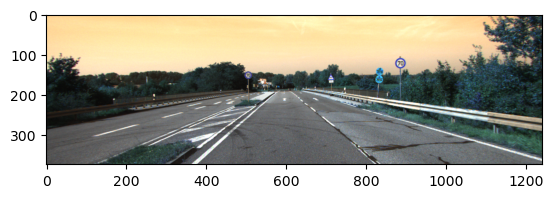

In [4]:
sample = images[10]

img = cv2.imread(os.path.join(image_dir, sample))
print("Image shape:", img.shape)

plt.imshow(img)

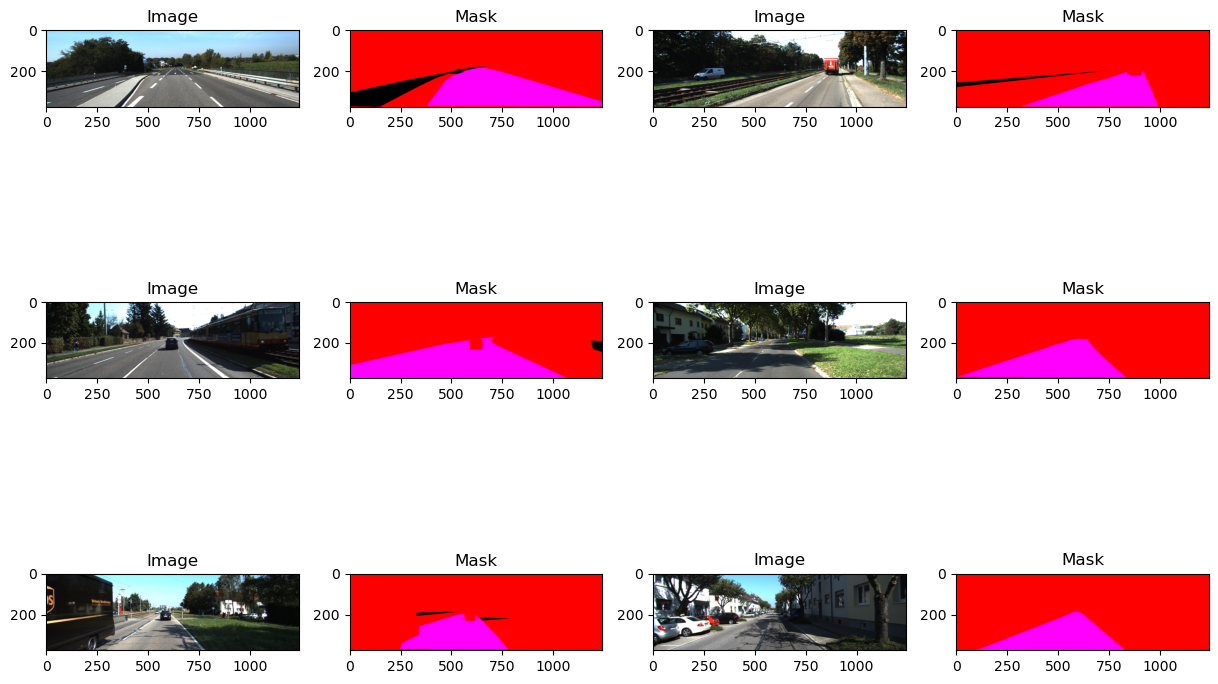

In [5]:
plt.figure(figsize=(15,10))

for i in range(6):

    sample = random.choice(images)

    prefix, rest = sample.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    img = cv2.imread(os.path.join(image_dir, sample))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(os.path.join(mask_dir, mask_name))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i*2+1)
    plt.imshow(img)
    plt.title("Image")

    plt.subplot(3,4,i*2+2)
    plt.imshow(mask)
    plt.title("Mask")

plt.show()

In [6]:
pixels = []

for img_name in images[:50]:
    img = cv2.imread(os.path.join(image_dir, img_name))
    pixels.append(img.mean())

print("Mean pixel intensity:", np.mean(pixels))

Mean pixel intensity: 94.87449656110216


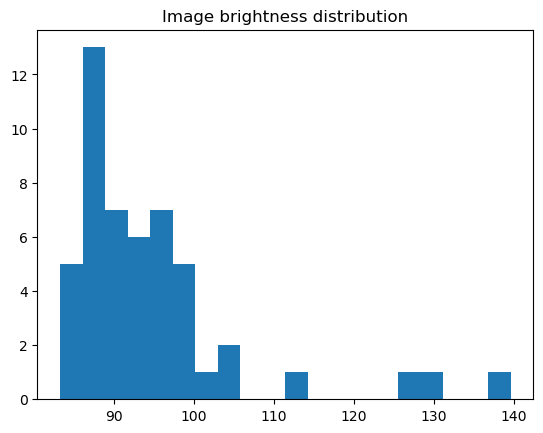

In [7]:
plt.hist(pixels, bins=20)
plt.title("Image brightness distribution")
plt.show()

In [8]:
for img_name in images[:5]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    print(img_name, "->", mask_name)

umm_000000.png -> umm_road_000000.png
umm_000001.png -> umm_road_000001.png
umm_000002.png -> umm_road_000002.png
umm_000004.png -> umm_road_000004.png
umm_000003.png -> umm_road_000003.png


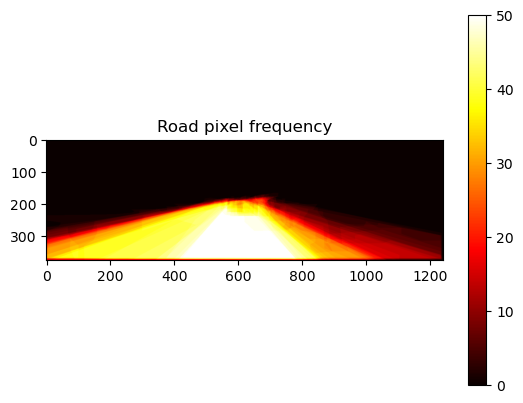

In [9]:
heatmap = np.zeros((375,1242))

for img_name in images[:50]:

    prefix, rest = img_name.split("_",1)
    mask_name = f"{prefix}_road_{rest}"

    mask = cv2.imread(os.path.join(mask_dir, mask_name))

    road = mask[:,:,0] == 255

    road = cv2.resize(road.astype(np.uint8), (1242,375))

    heatmap += road

plt.imshow(heatmap, cmap="hot")
plt.title("Road pixel frequency")
plt.colorbar()
plt.show()

In [10]:
def get_mask_name(img_name):
    prefix, rest = img_name.split("_",1)
    return f"{prefix}_road_{rest}"

In [11]:
IMG_SIZE = 256

def load_sample(img_name):

    img_path = os.path.join(image_dir, img_name)
    mask_path = os.path.join(mask_dir, get_mask_name(img_name))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)

    # road pixels
    road = mask[:,:,0] == 255
    mask = road.astype(np.float32)

    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

    mask = np.expand_dims(mask,axis=-1)

    return img, mask

In [12]:
X=[]
Y=[]

for img_name in images:
    
    img,mask = load_sample(img_name)

    X.append(img)
    Y.append(mask)

X = np.array(X)/255.0
Y = np.array(Y)

print(X.shape,Y.shape)

(289, 256, 256, 3) (289, 256, 256, 1)


In [13]:
from sklearn.model_selection import train_test_split

X_train,X_val,Y_train,Y_val = train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [14]:
def build_resnet_unet():

    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Encoder layers (skip connections)
    s1 = base.get_layer("conv1_relu").output
    s2 = base.get_layer("conv2_block3_out").output
    s3 = base.get_layer("conv3_block4_out").output
    s4 = base.get_layer("conv4_block6_out").output

    b1 = base.get_layer("conv5_block3_out").output

    # Decoder
    d1 = UpSampling2D((2,2))(b1)
    d1 = Concatenate()([d1,s4])
    d1 = Conv2D(512,3,padding="same",activation="relu")(d1)

    d2 = UpSampling2D((2,2))(d1)
    d2 = Concatenate()([d2,s3])
    d2 = Conv2D(256,3,padding="same",activation="relu")(d2)

    d3 = UpSampling2D((2,2))(d2)
    d3 = Concatenate()([d3,s2])
    d3 = Conv2D(128,3,padding="same",activation="relu")(d3)

    d4 = UpSampling2D((2,2))(d3)
    d4 = Concatenate()([d4,s1])
    d4 = Conv2D(64,3,padding="same",activation="relu")(d4)

    d5 = UpSampling2D((2,2))(d4)
    outputs = Conv2D(1,1,activation="sigmoid")(d5)

    model = Model(base.input,outputs)

    return model

In [15]:
model = build_resnet_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#model.summary()

I0000 00:00:1776874928.780279   23919 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5
W0000 00:00:1776874928.999416   24007 gpu_backend_lib.cc:579] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykern/cuda_nvcc
  
  /usr/local/cuda
  /opt/conda/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /opt/conda/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /opt/conda/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModule's DebugOptions.  For most apps, setting th

In [16]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val,Y_val),
    epochs=5,
    batch_size=16
)

Epoch 1/5


I0000 00:00:1776874961.918050   24000 service.cc:148] XLA service 0x7f2774002760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776874961.918081   24000 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776874966.296394   24000 cuda_dnn.cc:529] Loaded cuDNN version 91002


InternalError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/opt/conda/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/opt/conda/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/opt/conda/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/opt/conda/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/opt/conda/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/opt/conda/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/opt/conda/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 621, in shell_main

  File "/opt/conda/lib/python3.12/site-

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
import tarfile, os

model.export("/kaggle/working/road_seg_savedmodel")

with tarfile.open("/kaggle/working/model.tar.gz", "w:gz") as tar:
    tar.add("/kaggle/working/road_seg_savedmodel", arcname=".")

In [ ]:
idx = 4
pred = model.predict(X_val[idx:idx+1])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[idx])
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(Y_val[idx].squeeze())
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred[0].squeeze() > 0.5)
plt.title("Prediction")

plt.show()

In [ ]:
video_path = "/kaggle/input/datasets/sakshaymahna/kittiroadsegmentation/testing/solidYellowLeft.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(width, height, fps)

In [ ]:
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

out = cv2.VideoWriter("/kaggle/working/output.mp4",fourcc,fps,(width, height))

In [ ]:
IMG_SIZE = 256

def process_frame(frame):

    original = frame.copy()

    small = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    small = small / 255.0

    pred = model.predict(small[np.newaxis,...])[0]

    mask = pred.squeeze() > 0.5

    mask = cv2.resize(mask.astype(np.uint8), (width, height))

    overlay = original.copy()
    overlay[mask == 1] = [0,255,0]

    return overlay

In [ ]:
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    result = process_frame(frame)
    out.write(result)
cap.release()
out.release()